# Copula-GARCH

In [538]:
import numpy as np
import pandas as pd

from arch import arch_model 

from copulae import pseudo_obs # function to get pseudo-observations for copula fitting
from copulae import GaussianCopula

from scipy.stats import t # t-distribution for back-transformation of simulated pseudo-observations
from scipy import stats # t-distribution for back-transformation of simulated pseudo-observations

import yfinance as yf

import matplotlib.pyplot as plt

from scipy import stats as sps
from scipy.stats import chi2

import pyreadr

## Functions

### Fitting GARCH models

In [ ]:
def fit_garch(returns, scale=100):
    """
    Fit a ARMA(1,1)-GARCH(1,1) model to the returns and return the fitted model.
    """
    model = arch_model(returns*scale, mean="AR", lags=1, vol="Garch", p=1, q=1, dist="t") # scale returns for better convergence

    res = model.fit(disp="off", show_warning=False) # disp="off" to suppress output, show_warning=False to ignore convergence warnings

    return res

In [ ]:
def fit_garch_constmean(returns, garch_order=(1, 1), dist="t", horizon=1, scale=100):
    """
    Fit GARCH(1,1) model with Student-t innovations using the `arch` packages.
    Parameters:
        - returns: Array-like, the return series to be modeled.
        - garch_order: Tuple, the order of the GARCH model (default is (1, 1)).
        - dist: String, the distribution of the innovations (default is "t" for Student-t).
        - horizon: Int, the number of periods to forecast (default is 1).
        - scale: Float, a scaling factor for the returns to improve convergence (default is 100).
    Returns:
        - A dictionary containing:
            - residuals_std: Array, standardized residuals (innovations) from the fitted model.
            - mu: Float, forecasted mean for the next period(s).
            - sigma: Float, forecasted conditional volatility for the next period(s).
            - nu: Float or None, degrees of freedom for the t-distribution (if dist is "t"), otherwise None.
    """
    from arch import arch_model
    import numpy as np

    p, q = garch_order
    res_garch = arch_model(returns*scale, mean="Constant", vol="Garch", p=p, q=q, dist=dist).fit(disp="off", show_warning=False) # mean="Zero" because the mean process is already captured by the ARMA model
    nu = res_garch.params["nu"] if dist == "t" else None # degrees of freedom for the t-distribution
    residuals_std = res_garch.std_resid # standardized residuals (innovations)

    sigma1 = np.sqrt(res_garch.forecast(horizon=horizon).variance.values[-1, 0]) / scale # forecasted volatility from GARCH model; scale back to original units
    mu1 = res_garch.forecast(horizon=horizon).mean.iloc[-1, 0] / scale # forecasted mean return from the ARMA model; scale back to original units

    return {"residuals_std": residuals_std, "mu": mu1, "sigma": sigma1, "nu": nu}

### Fit copulas

In [560]:
def fit_copula_gaussian(matrix_residuals_std):
    """
    Fit a Gaussian copula to the standardized residuals from GARCH models. 

    Parameters:
        - matrix_residuals_std: 2D array, standardized residuals for each asset (columns) and time points (rows).
    Returns:
        - copula: Fitted Gaussian copula object.
    """
    from copulae import GaussianCopula

    u = pseudo_obs(matrix_residuals_std) # Convert standardized residuals to pseudo-observations (ranks scaled to [0,1])
    copula = GaussianCopula(dim=matrix_residuals_std.shape[1]) # Initialize Gaussian copula
    copula.fit(u) # Fit the copula to the pseudo-observations

    return copula

def fit_copula_t(matrix_residuals_std):
    """
    Fit a t-copula to the standardized residuals from GARCH models. 
    Parameters:
        - matrix_residuals_std: 2D array, standardized residuals for each asset (columns) and time points (rows).
    Returns:
        - copula: Fitted t-copula object.
    """
    from copulae import TCopula

    u = pseudo_obs(matrix_residuals_std) # Convert standardized residuals to pseudo-observations (ranks scaled to [0,1])
    copula = TCopula(dim=matrix_residuals_std.shape[1]) # Initialize t-copula
    copula.fit(u) # Fit the copula to the pseudo-observations

    return copula

def fit_copula_clayton(matrix_residuals_std):
    """
    Fit a Clayton copula to the standardized residuals from GARCH models. 
    Parameters:
        - matrix_residuals_std: 2D array, standardized residuals for each asset (columns) and time points (rows).
    Returns:
        - copula: Fitted Clayton copula object.
    """
    from copulae.archimedean import ClaytonCopula

    u = pseudo_obs(matrix_residuals_std) # Convert standardized residuals to pseudo-observations (ranks scaled to [0,1])
    copula = ClaytonCopula(dim=matrix_residuals_std.shape[1]) # Initialize Clayton copula
    copula.fit(u, method="itau") # Fit the copula to the pseudo-observations

    return copula

### Sampling: Simulate new data from copula

In [352]:
def simulate_copula(copula, n_sim=10000):
    """
    Simulate data from a fitted copula. 
    Parameters:
        - copula: Fitted copula object (GaussianCopula or TCopula).
        - n_sim: Number of simulations to generate. 
    Returns:
        - random: Simulated data from the copula.
    """
    u_sim = copula.random(n_sim) # Simulate data from the fitted copula
    return u_sim

### Backtesting

In [637]:
def get_exceedances(realized, var_forecast):
    """
    Computes the hit sequence of VaR exceedances, i.e. a binary array where 1 indicates that the realized return was 
    less than the forecasted VaR (i.e. an exceedance), and 0 otherwise.

    Get binary array of exceedances (1 if return < VaR forecast, else 0).
    
    Parameters:
        - realized: Array-like, the realized returns.
        - var_forecast: Array-like, the forecasted VaR values.
    Returns:
        - Array of 0s and 1s indicating whether each return was an exceedance of the VaR forecast.

    """
    return (realized < var_forecast).astype(int)


def kupiec_pof_test(violations: np.ndarray, alpha: float) -> dict:
    """
    Kupiec Proportion-of-Failures Test (unconditional coverage).
    H0: Die tatsächliche Verletzungsrate entspricht dem erwarteten Niveau alpha.

    Parameters:
        - violations: Array-like, binary array where 1 indicates a VaR exceedance (realized return < VaR forecast) and 0 otherwise.
        - alpha: Float, the theoretical violation rate (e.g., 0.05 for 5% VaR).
    Returns:
        - Dictionary containing:
            - n: Total number of observations.
            - violations: Total number of exceedances (sum of the violations array).
            - expected: Expected number of exceedances under the null hypothesis (n * alpha).
            - vr: Empirical violation rate (violations / n).
            - LR: Likelihood ratio test statistic for the Kupiec test.
            - p_value: p-value for the Kupiec test statistic.
    """
    import numpy as np
    from scipy import stats

    n = len(violations)
    x = int(violations.sum())
    if n == 0:
        return {"n": 0, "violations": 0, "expected": 0, "vr": np.nan, "LR": np.nan, "p_value": np.nan}

    pi_hat = x / n
    # Edge cases: keine oder nur Verletzungen
    if x == 0:
        ll1 = 0.0
    elif x == n:
        ll1 = 0.0
    else:
        ll1 = x * np.log(pi_hat) + (n - x) * np.log(1 - pi_hat)
    ll0 = x * np.log(alpha) + (n - x) * np.log(1 - alpha)

    LR = -2.0 * (ll0 - ll1)
    p = 1.0 - stats.chi2.cdf(LR, df=1)
    return {"n": n, "violations": x, "expected": n * alpha, "vr": pi_hat, "LR": float(LR), "p_value": float(p)}


def christoffersen_independence_test(violations: np.ndarray) -> dict:
    """
    Christoffersen (1998) Independence Test via 2-State Markov chain.

    H0: Die Verletzungen sind unabhängig über die Zeit (keine Clusterbildung von Verletzungen).

    Parameters:
        - violations: Array-like, binary array where 1 indicates a VaR exceedance (realized return < VaR forecast) and 0 otherwise.
    Returns:
        - Dictionary containing:
            - LR: Likelihood ratio test statistic for the Christoffersen independence test.
            - p_value: p-value for the Christoffersen independence test statistic.
            - n00: Count of transitions from 0 to 0 (no violation followed by no violation).
            - n01: Count of transitions from 0 to 1 (no violation followed by violation).
            - n10: Count of transitions from 1 to 0 (violation followed by no violation).
            - n11: Count of transitions from 1 to 1 (violation followed by violation).
    """
    import numpy as np
    from scipy import stats

    v = np.asarray(violations).astype(int)
    n = len(v)
    if n < 2:
        return {"LR": np.nan, "p": np.nan}

    # Transition counts
    n00 = int(np.sum((v[:-1] == 0) & (v[1:] == 0)))
    n01 = int(np.sum((v[:-1] == 0) & (v[1:] == 1)))
    n10 = int(np.sum((v[:-1] == 1) & (v[1:] == 0)))
    n11 = int(np.sum((v[:-1] == 1) & (v[1:] == 1)))

    # Transition probabilities (geschützt gegen 0/0)
    pi01 = n01 / (n00 + n01) if (n00 + n01) > 0 else 0.0
    pi11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0.0
    pi   = (n01 + n11) / (n00 + n01 + n10 + n11)

    # Log-Likelihoods
    def _safe_log(p): return np.log(p) if p > 0 else 0.0

    ll_indep = ((n01 + n11) * _safe_log(pi)
                + (n00 + n10) * _safe_log(1 - pi))
    ll_markov = (n00 * _safe_log(1 - pi01) + n01 * _safe_log(pi01)
                 + n10 * _safe_log(1 - pi11) + n11 * _safe_log(pi11))

    LR = -2.0 * (ll_indep - ll_markov)
    p = 1.0 - stats.chi2.cdf(LR, df=1)
    return {"LR": float(LR), "p_value": float(p),
            "n00": n00, "n01": n01, "n10": n10, "n11": n11}


def christoffersen_cc_test(violations: np.ndarray, alpha: float) -> dict:
    """
    Conditional Coverage Test (Kupiec + Independence kombiniert).
    H0: Die Verletzungen haben die richtige durchschnittliche Rate (alpha) UND sind unabhängig über die Zeit.
    Parameters:
    - violations: Array-like, binary array where 1 indicates a VaR exceedance (realized return < VaR forecast) and 0 otherwise.
    - alpha: Float, the theoretical violation rate (e.g., 0.05 for 5% VaR).
    Returns:
    - Dictionary containing:
        - LR: Likelihood ratio test statistic for the conditional coverage test.
        - p_value: p-value for the conditional coverage test statistic.
    """
    import numpy as np
    from scipy import stats

    uc = kupiec_pof_test(violations, alpha)
    ind = christoffersen_independence_test(violations)
    if np.isnan(uc["LR"]) or np.isnan(ind["LR"]):
        return {"LR": np.nan, "p_value": np.nan}
    LR_cc = uc["LR"] + ind["LR"]
    p = 1.0 - stats.chi2.cdf(LR_cc, df=2)
    return {"LR": float(LR_cc), "p_value": float(p)}


def run_backtests(var_df: pd.DataFrame,
                  realized: pd.Series,
                  alpha: float) -> pd.DataFrame:
    """
    Backtests für alle Modelle in `var_df` zum Niveau `alpha`.

    Parameters
    ----------
    var_df   : DataFrame mit VaR-Forecasts (Spalten = Modelle).  In deinem
               Setup sind das Quantile, also typischerweise NEGATIVE Zahlen
               für Verluste.  Eine Verletzung ist  r_t < VaR_t.
    realized : Realisierte Portfolio-Returns (gleicher Index wie var_df).
    alpha    : Theoretisches Verletzungsniveau (z.B. 0.05 oder 0.01).
    """
    import pandas as pd

    rows = []
    for model in var_df.columns:
        var_series = var_df[model].astype(float)
        viol = (realized.values < var_series.values).astype(int)

        uc  = kupiec_pof_test(viol, alpha)
        ind = christoffersen_independence_test(viol)
        cc  = christoffersen_cc_test(viol, alpha)

        rows.append({
            "Model":              model,
            "Alpha":              alpha,
            "N":                  uc["n"],
            "Violations":         uc["violations"],
            "Expected":           round(alpha * uc["n"], 2),
            "Violation Rate":     uc["vr"],
            "Kupiec LR":          uc["LR"],
            "Kupiec p_value":           round(uc["p_value"], 4),
            "Independence LR":    ind["LR"],
            "Independence p_value":     round(ind["p_value"], 4),
            "CC LR":              cc["LR"],
            "CC p_value":               round(cc["p_value"], 4),
        })
    return pd.DataFrame(rows).set_index("Model")


In [641]:
def christoffersen_pelletier_duration_test(violations: np.ndarray, alpha: float) -> dict:
    """
    Christoffersen & Pelletier (2004) Duration-Based Test of Independence.

    H0: Die Dauern zwischen aufeinanderfolgenden VaR-Verletzungen sind exponentialverteilt
        mit Parameter alpha (d.h. memorylos / keine Clusterbildung).
    H1: Die Dauern folgen einer Weibull-Verteilung mit Shape-Parameter b != 1
        (b < 1 => Clustering, b > 1 => zu regelmäßige Verletzungen).

    Die Exponentialverteilung ist ein Spezialfall der Weibull-Verteilung mit b = 1.
    Der Test ist ein Likelihood-Ratio-Test mit 1 Freiheitsgrad.

    Parameters:
        - violations: Array-like, binary array where 1 indicates a VaR exceedance
                      (realized return < VaR forecast) and 0 otherwise.
        - alpha: Float, the theoretical violation rate (e.g., 0.05 for 5% VaR).
                 Wird nur informativ zurückgegeben; die MLE schätzt a und b frei.
    Returns:
        - Dictionary containing:
            - LR: Likelihood ratio test statistic.
            - p_value: p-value (chi-squared with 1 df).
            - b_hat: Geschätzter Weibull-Shape-Parameter (b=1 unter H0).
            - a_hat: Geschätzter Weibull-Scale-Parameter unter H1.
            - n_durations: Anzahl der berechneten Dauern.
            - n_violations: Gesamtanzahl der Verletzungen.
    """
    import numpy as np
    from scipy import stats, optimize

    v = np.asarray(violations).astype(int)
    n = len(v)
    n_viol = int(v.sum())

    # Mindestens 2 Verletzungen nötig, damit es mindestens eine "vollständige" Dauer gibt
    if n_viol < 2:
        return {"LR": np.nan, "p_value": np.nan, "b_hat": np.nan,
                "a_hat": np.nan, "n_durations": 0, "n_violations": n_viol}

    # Indizes der Verletzungen
    hit_idx = np.where(v == 1)[0]

    # Dauern zwischen aufeinanderfolgenden Verletzungen (no-hit Tage + 1)
    # D_i = t_i - t_{i-1}  (Anzahl Tage zwischen Hit i-1 und Hit i)
    durations = np.diff(hit_idx).astype(float)

    # Zensierte Dauern an den Rändern:
    # - vor der ersten Verletzung: hit_idx[0] + 1 Tage bis zur ersten Verletzung
    # - nach der letzten Verletzung: n - 1 - hit_idx[-1] Tage ohne weitere Verletzung
    d_first = float(hit_idx[0] + 1)            # links zensiert (kein vorheriger Hit beobachtet)
    d_last  = float(n - 1 - hit_idx[-1])       # rechts zensiert (kein nachfolgender Hit beobachtet)

    # Wir behandeln die Randdauern als rechtszensiert: wir wissen nur, dass D >= d_first
    # bzw. D >= d_last. (Standardvorgehen in Christoffersen & Pelletier 2004.)
    # Vollständig beobachtete Dauern:
    d_obs = durations
    # Zensierte Dauern (nur falls > 0):
    d_cens = []
    if d_first > 0:
        d_cens.append(d_first)
    if d_last > 0:
        d_cens.append(d_last)
    d_cens = np.array(d_cens, dtype=float)

    # ---------- Log-Likelihoods ----------
    # Weibull-Dichte (parametrisiert wie in C&P 2004):
    #   f(d; a, b) = a * b * (a*d)^(b-1) * exp(-(a*d)^b)
    #   S(d; a, b) = exp(-(a*d)^b)    (Survivor)
    # Exponentialverteilung: b = 1 => f(d; a) = a * exp(-a*d), S(d; a) = exp(-a*d)
    # MLE für Exponential mit Zensierung: a_hat = (#vollst. beobachtungen) / (Summe aller d)
    #
    # H0 (Exponential): wir schätzen a frei (oder fixieren a = alpha — siehe Hinweis unten).
    # H1 (Weibull): wir schätzen a und b frei.

    def neg_ll_weibull(params, d_obs, d_cens):
        a, b = params
        if a <= 0 or b <= 0:
            return 1e10
        # Beitrag vollständiger Beobachtungen: log f(d; a, b)
        ll_obs = np.sum(np.log(a) + np.log(b) + (b - 1) * np.log(a * d_obs) - (a * d_obs) ** b)
        # Beitrag zensierter Beobachtungen: log S(d; a, b) = -(a*d)^b
        if len(d_cens) > 0:
            ll_cens = -np.sum((a * d_cens) ** b)
        else:
            ll_cens = 0.0
        return -(ll_obs + ll_cens)

    def neg_ll_exp(a, d_obs, d_cens):
        if a <= 0:
            return 1e10
        ll_obs = np.sum(np.log(a) - a * d_obs)
        if len(d_cens) > 0:
            ll_cens = -a * np.sum(d_cens)
        else:
            ll_cens = 0.0
        return -(ll_obs + ll_cens)

    # ---------- H0: Exponential MLE ----------
    # Geschlossene Form mit Zensierung: a_hat = (#vollst. beobachtungen) / (Summe aller Dauern)
    total_time = float(d_obs.sum() + d_cens.sum())
    if total_time <= 0:
        return {"LR": np.nan, "p_value": np.nan, "b_hat": np.nan,
                "a_hat": np.nan, "n_durations": len(d_obs), "n_violations": n_viol}
    a_hat_h0 = len(d_obs) / total_time
    ll_h0 = -neg_ll_exp(a_hat_h0, d_obs, d_cens)

    # ---------- H1: Weibull MLE ----------
    # Startwerte: a = a_hat_h0, b = 1
    res = optimize.minimize(
        neg_ll_weibull,
        x0=[a_hat_h0, 1.0],
        args=(d_obs, d_cens),
        method="Nelder-Mead",
        options={"xatol": 1e-8, "fatol": 1e-8, "maxiter": 5000}
    )
    if not res.success:
        return {"LR": np.nan, "p_value": np.nan, "b_hat": np.nan,
                "a_hat": np.nan, "n_durations": len(d_obs), "n_violations": n_viol}
    a_hat_h1, b_hat_h1 = res.x
    ll_h1 = -res.fun

    # ---------- LR-Test ----------
    LR = -2.0 * (ll_h0 - ll_h1)
    # Numerischer Schutz: LR sollte >= 0 sein
    LR = max(LR, 0.0)
    p_value = 1.0 - stats.chi2.cdf(LR, df=1)

    return {
        "LR": float(LR),
        "p_value": float(p_value),
        "b_hat": float(b_hat_h1),
        "a_hat": float(a_hat_h1),
        "n_durations": len(d_obs),
        "n_violations": n_viol,
    }

### MAD

In [681]:
def calculate_mad(df: pd.DataFrame) -> pd.Series:
    """
    Berechnet den MAD.

    Parameter
    ----------
    df : pd.DataFrame
        Jede Spalte = Copula-Modell
        Jede Zeile = Zeitpunkt / Tag
        Werte = VaR-Schätzungen

    Returns
    -------
    pd.Series
        MAD pro Tag
    """
    # Durchschnittlicher VaR pro Tag
    row_mean = df.mean(axis=1)

    # Absolute Abweichungen vom Tagesmittel
    abs_dev = df.sub(row_mean, axis=0).abs()

    # Mean Absolute Deviation pro Tag
    mad = abs_dev.mean(axis=1)

    return mad


def mad_summary_statistics(
    mad_series: pd.Series,
    portfolio_value: float = 100_000,
    horizon_days: int = 10
) -> pd.DataFrame:
    """
    Berechnet die Summary-Statistiken des MAD wie in Table 2.

    Erwartet MAD-Werte als Dezimalzahlen:
    Beispiel:
        0.025 = 2.5%

    Returns
    -------
    pd.DataFrame
        Tabelle mit:
        - MAD (%)
        - MAD ($)
    """

    import numpy as np
    import pandas as pd

    # Statistiken aus Dezimalwerten
    stats_decimal = pd.Series({
        "Min": mad_series.min(),
        "Median": mad_series.median(),
        "Mean": mad_series.mean(),
        "Max": mad_series.max(),
        "SD": mad_series.std()
    })

    # In Prozent umrechnen
    stats_percent = stats_decimal * 100

    # Dollar-Skalierung wie im Paper
    scale = portfolio_value * np.sqrt(horizon_days)

    stats_dollar = stats_decimal * scale

    # Ergebnis
    result = pd.DataFrame({
        "MAD (%)": stats_percent,
        "MAD ($)": stats_dollar
    })

    return result

## 1. Basics

### 1.1 Load data

In [574]:
TICKERS = ["NVDA", "AAPL", "WMT", "LLY", "JPM"]
prices = yf.download(TICKERS, start="2022-01-01", end="2024-06-30")["Close"]
returns = np.log(prices / prices.shift(1)).dropna() # log returns
returns.head()

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,JPM,LLY,NVDA,WMT
Date,,,,,
2022-01-04,-0.012773,0.037209,-0.018272,-0.027976,-0.018490
2022-01-05,-0.026960,-0.018451,-0.023358,-0.059286,0.013431
2022-01-06,-0.016834,0.010568,-0.005077,0.020581,-0.002783
2022-01-07,0.000988,0.009859,0.000655,-0.033598,0.009500
2022-01-10,0.000116,0.000957,0.002348,0.005600,-0.001934


In [580]:
returns = pd.read_csv("/Users/andre/Documents/machinelearning/data/qrm2025_returns.csv")
returns = returns.iloc[1:]
returns.head()

,STOXX_EU_600,DOWJONES_INDUSTRIALS,MSCI_EM,S&P_U.S._TREASURY_BOND,S&P_GSCI_Commodity
1,0.021227,0.014988,0.015312,0.001415,0.025407
2,-0.001757,-0.001128,0.010706,0.002608,0.000994
3,-0.000513,0.000798,0.006397,-0.002013,0.017457
4,-0.003961,0.003267,-0.007171,-0.000337,-0.009653
5,0.004198,0.001069,0.001962,0.001275,-0.000069


In [536]:
returns.columns

Index(['STOXX_EU_600', 'DOWJONES_INDUSTRIALS', 'MSCI_EM',
       'S&P_U.S._TREASURY_BOND', 'S&P_GSCI_Commodity'],
      dtype='str')

In [571]:
len(returns)

2346

### 1.2 Configuration

In [582]:
WINDOW = 500
N_FORECAST = len(returns) - WINDOW
N_SIM = 10000

ALPHA = 0.05, 0.01 # Signifikanzniveaus für VaR-Berechnung

SCALE = 100 # scale factor for returns to improve GARCH convergence

SEED = 42

weights = np.ones(len(TICKERS)) / len(TICKERS)
N_FORECAST

1846

## 2. Rolling window

### Initializing DFs

In [533]:
# Initializing DataFrames to store VaR results and realized returns for the forecast period
fcst_idx = returns.index[WINDOW: WINDOW + N_FORECAST] # Index für die nächsten 100 Tage, für die wir Vorhersagen machen wollen

# var5 = pd.DataFrame(index=fcst_idx, columns=["Gaussian Copula", "t Copula"], dtype=float)
# var1 = pd.DataFrame(index=fcst_idx, columns=["Gaussian Copula", "t Copula"], dtype=float)

var_5_alt = pd.Series(index=fcst_idx, dtype=float, name='VaR_5%')
var_1_alt = pd.Series(index=fcst_idx, dtype=float, name='VaR_1%')

var_5_hs = pd.Series(index=fcst_idx, dtype=float, name='VaR_5%_HS')
var_1_hs = pd.Series(index=fcst_idx, dtype=float, name='VaR_1%_HS')

realized = pd.Series(index=fcst_idx, dtype=float, name='realized')

### Rolling window

#### Gaussian copula

In [534]:
for t in range(N_FORECAST): # Die Variable t läuft von 0 bis N_FORECAST-1; Für jede Iteration wird eine neue Prognose berechnet

    window_returns = returns.iloc[t:t+WINDOW] # rolling window of returns for model fitting
    window_pf_returns = returns.iloc[t:t+WINDOW].dot(weights)

    # --- Fit GARCH models to the rolling window ------------------------------------------------------
    garch_fits = {c: fit_garch_constmean(window_returns[c], garch_order=(1, 1), dist="t", horizon=1, scale=SCALE) for c in returns.columns}
    
    # --- Fit Copula to Standardized Residuals ------------------------------------------------------
    matrix_residuals_std = np.array([f["residuals_std"] for f in garch_fits.values()]).T # matrix of standardized residuals (time points x assets)
    copula_gaussian = fit_copula_gaussian(matrix_residuals_std)

    # --- Sampling: Simulate new data (uniform data) from copulas ------------------------------------------------------
    u_sim = simulate_copula(copula_gaussian, n_sim=N_SIM)

    # --- Backtransformation: Inverse PIT -> z_sim ------------------------------------------------------
    nu = np.column_stack([f["nu"] for f in garch_fits.values()]) # degrees of freedom for the t-distribution from GARCH fits; shape: (1, number of assets)  
    z_sim = stats.t.ppf(u_sim, df=nu) # Back-transform the simulated pseudo-observations to the original scale using the inverse CDF of the standardized residuals; t-distribution with asset-specific degrees of freedom from GARCH fits

    # --- Simulated returns: r_sim = mu + sigma * z_sim ------------------------------------------------------
    vec_mu = np.column_stack([f["mu"] for f in garch_fits.values()])
    vec_sigma = np.column_stack([f["sigma"] for f in garch_fits.values()])
    r_sim = vec_mu + vec_sigma * z_sim # Simulated returns for the next period based on the simulated standardized residuals and the forecasted mean and volatility from GARCH models

    # --- Simulated portfolio returns: pf_sim = r_sim * weights ------------------------------------------------------
    pf_sim = np.dot(r_sim, weights)

    # --- Risk measure forecasts and storage ------------------------------------------------------
    var_5_alt.iloc[t] = np.percentile(pf_sim, ALPHA[0]) # VaR at 5% level
    var_1_alt.iloc[t] = np.percentile(pf_sim, ALPHA[1]) # VaR at 1% level

    var_5_hs.iloc[t] = np.percentile(window_pf_returns, ALPHA[0]) # Historical Simulation VaR at 5% level
    var_1_hs.iloc[t] = np.percentile(window_pf_returns, ALPHA[1]) # Historical Simulation VaR at 1% level

    # --- Store realized portfolio return for the forecast day ------------------------------------------------------
    realized.iloc[t] = returns.iloc[t+WINDOW].dot(weights)

/opt/anaconda3/envs/ml/lib/python3.13/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.05951. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/opt/anaconda3/envs/ml/lib/python3.13/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.05961. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/opt/anaconda3/envs/ml/lib/python3.13/site

##### Plot risk measures

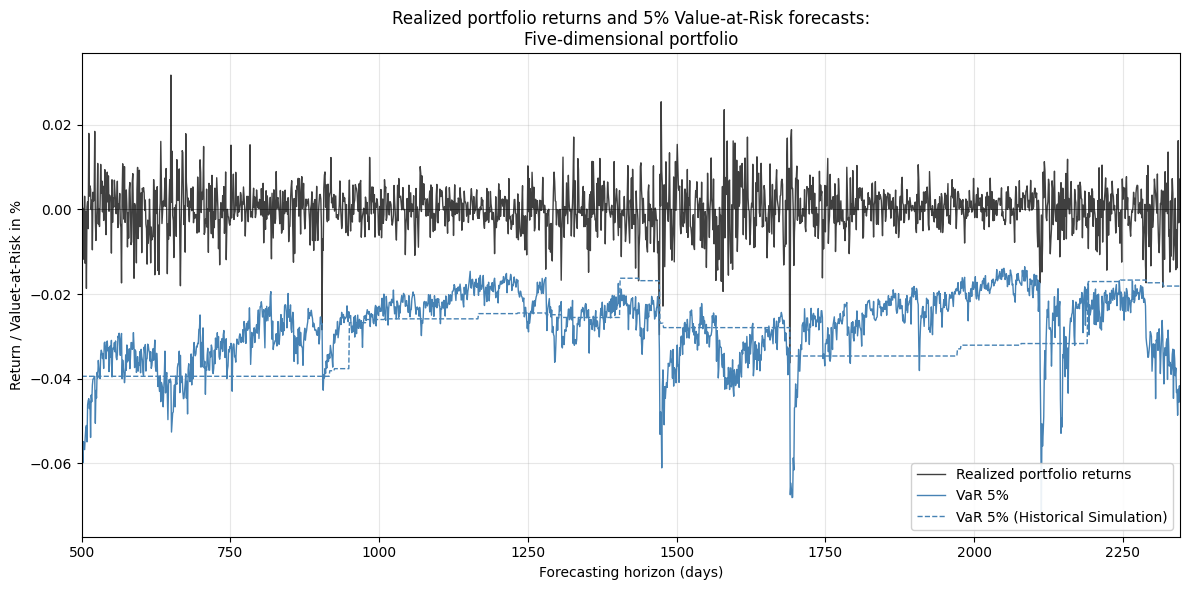

In [535]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(realized.index, realized.values, color="black", lw=1, alpha=0.75, label="Realized portfolio returns")
ax.plot(var_5_alt.index, var_5_alt.values, color="steelblue", lw=1, label="VaR 5%")
ax.plot(var_5_hs.index, var_5_hs.values, color="steelblue", lw=1, ls="--", label="VaR 5% (Historical Simulation)")

ax.axhline(0, color="black", lw=0.5, alpha=0.5)
ax.set_xlabel("Forecasting horizon (days)")
ax.set_ylabel("Return / Valuet-at-Risk in %")
ax.set_xlim(realized.index[0], realized.index[-1])
ax.set_title("Realized portfolio returns and 5% Value-at-Risk forecasts:\nFive-dimensional portfolio")
ax.legend(loc="lower right", framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Multiple copulas: Gaussian, t, Clayton with t-distributed innovoations

In [583]:
# Initializing DataFrames to store VaR results and realized returns for the forecast period
fcst_idx = returns.index[WINDOW: WINDOW + N_FORECAST] # Index für die nächsten 100 Tage, für die wir Vorhersagen machen wollen

var5 = pd.DataFrame(index=fcst_idx, columns=["GaussianCopula", "tCopula", "ClaytonCopula", "HS"], dtype=float)
var1 = pd.DataFrame(index=fcst_idx, columns=["GaussianCopula", "tCopula", "ClaytonCopula", "HS"], dtype=float)

realized = pd.Series(index=fcst_idx, dtype=float, name='realized')

# Rolling window
for t in range(N_FORECAST): # Die Variable t läuft von 0 bis N_FORECAST-1; Für jede Iteration wird eine neue Prognose berechnet

    window_returns = returns.iloc[t:t+WINDOW] # rolling window of returns for model fitting
    window_pf_returns = returns.iloc[t:t+WINDOW].dot(weights)

    # --- Fit GARCH models to the rolling window ------------------------------------------------------
    garch_fits = {c: fit_garch_constmean(window_returns[c], garch_order=(1, 1), dist="t", horizon=1, scale=SCALE) for c in returns.columns}
    
    # --- Fit Copula to Standardized Residuals ------------------------------------------------------
    matrix_residuals_std = np.array([f["residuals_std"] for f in garch_fits.values()]).T # matrix of standardized residuals (time points x assets)
    copula_gaussian = fit_copula_gaussian(matrix_residuals_std)
    copula_t = fit_copula_t(matrix_residuals_std)
    copula_clayton = fit_copula_clayton(matrix_residuals_std)

    # --- Sampling: Simulate new data (uniform data) from copulas ------------------------------------------------------
    u_sim_gaussian = simulate_copula(copula_gaussian, n_sim=N_SIM)
    u_sim_t = simulate_copula(copula_t, n_sim=N_SIM)
    u_sim_clayton = simulate_copula(copula_clayton, n_sim=N_SIM)

    # --- Backtransformation: Inverse PIT -> z_sim ------------------------------------------------------
    nu = np.column_stack([f["nu"] for f in garch_fits.values()]) # degrees of freedom for the t-distribution from GARCH fits; shape: (1, number of assets)  
    z_sim_gaussian = stats.t.ppf(u_sim_gaussian, df=nu) # Back-transform the simulated pseudo-observations to the original scale using the inverse CDF of the standardized residuals; t-distribution with asset-specific degrees of freedom from GARCH fits
    z_sim_t = stats.t.ppf(u_sim_t, df=nu) # Back-transform the simulated pseudo-observations to the original scale using the inverse CDF of the standardized residuals; t-distribution with asset-specific degrees of freedom from GARCH fits
    z_sim_clayton = stats.t.ppf(u_sim_clayton, df=nu) # Back-transform the simulated pseudo-observations to the original scale using the inverse CDF of the standardized residuals; t-distribution with asset-specific degrees of freedom from GARCH fits

    # --- Simulated returns: r_sim = mu + sigma * z_sim ------------------------------------------------------
    vec_mu = np.column_stack([f["mu"] for f in garch_fits.values()])
    vec_sigma = np.column_stack([f["sigma"] for f in garch_fits.values()])
    r_sim_gaussian = vec_mu + vec_sigma * z_sim_gaussian # Simulated returns for the next period based on the simulated standardized residuals and the forecasted mean and volatility from GARCH models
    r_sim_t = vec_mu + vec_sigma * z_sim_t # Simulated returns for the next period based on the simulated standardized residuals and the forecasted mean and volatility from GARCH models
    r_sim_clayton = vec_mu + vec_sigma * z_sim_clayton # Simulated returns for the next period based on the simulated standardized residuals and the forecasted mean and volatility from GARCH models

    # --- Simulated portfolio returns: pf_sim = r_sim * weights ------------------------------------------------------
    pf_sim_gaussian = np.dot(r_sim_gaussian, weights)
    pf_sim_t = np.dot(r_sim_t, weights)
    pf_sim_clayton = np.dot(r_sim_clayton, weights)

    # --- Risk measure forecasts and storage ------------------------------------------------------
    var5.loc[var5.index[t], "GaussianCopula"] = np.percentile(pf_sim_gaussian, ALPHA[0]) # VaR at 5% level
    var1.loc[var1.index[t], "GaussianCopula"] = np.percentile(pf_sim_gaussian, ALPHA[1]) # VaR at 1% level
    
    var5.loc[var5.index[t], "tCopula"] = np.percentile(pf_sim_t, ALPHA[0]) # VaR at 5% level
    var1.loc[var1.index[t], "tCopula"] = np.percentile(pf_sim_t, ALPHA[1]) # VaR at 1% level

    var5.loc[var5.index[t], "ClaytonCopula"] = np.percentile(pf_sim_clayton, ALPHA[0]) # VaR at 5% level
    var1.loc[var1.index[t], "ClaytonCopula"] = np.percentile(pf_sim_clayton, ALPHA[1]) # VaR at 1% level

    var5.loc[var5.index[t], "HS"] = np.percentile(window_pf_returns, ALPHA[0]) # Historical Simulation VaR at 5% level
    var1.loc[var1.index[t], "HS"] = np.percentile(window_pf_returns, ALPHA[1]) # Historical Simulation VaR at 1% level

    # --- Store realized portfolio return for the forecast day ------------------------------------------------------
    realized.iloc[t] = returns.iloc[t+WINDOW].dot(weights)

/opt/anaconda3/envs/ml/lib/python3.13/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.05961. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/opt/anaconda3/envs/ml/lib/python3.13/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.05959. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/opt/anaconda3/envs/ml/lib/python3.13/site

##### Plot risk measures

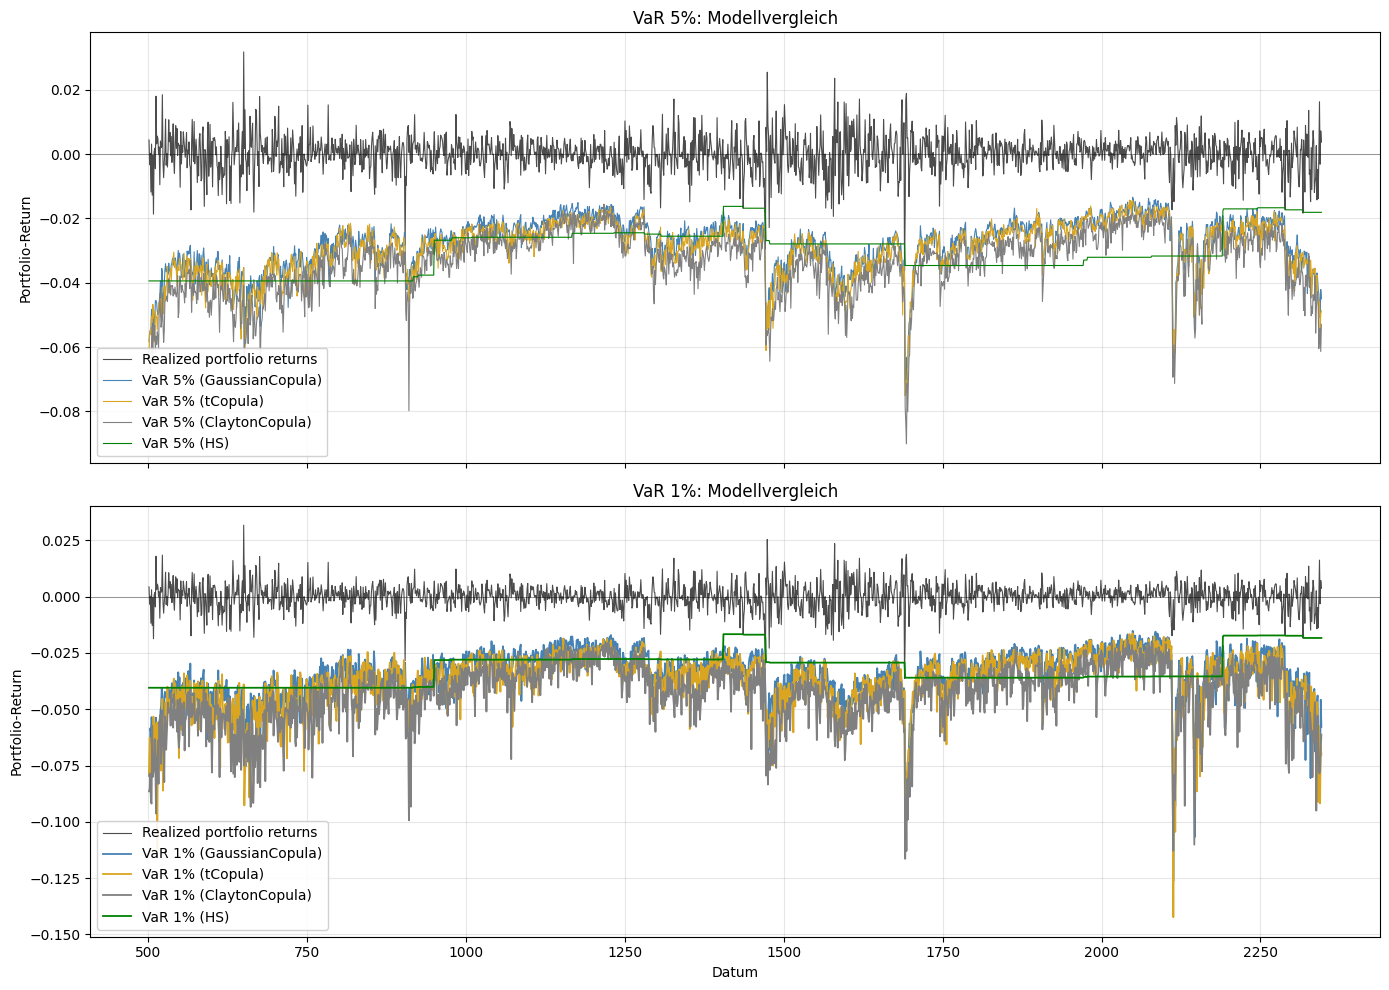

In [593]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

colors = {"GaussianCopula": "steelblue", "tCopula": "goldenrod", "ClaytonCopula": "grey", "HS": "green"}

# --- Subplot 1: VaR 5% ---
ax = axes[0]
ax.plot(realized.index, realized.values, color="black", lw=0.8,
        alpha=0.7, label="Realized portfolio returns")

for model in var5.columns:
    ax.plot(var5.index, var5[model], color=colors[model], lw=0.8,
            label=f"VaR 5% ({model})")

ax.axhline(0, color="black", lw=0.5, alpha=0.5)
ax.set_ylabel("Portfolio-Return")
ax.set_title("VaR 5%: Modellvergleich")
ax.legend(loc="lower left", framealpha=0.9)
ax.grid(True, alpha=0.3)

# --- Subplot 2: VaR 1% ---
ax = axes[1]
ax.plot(realized.index, realized.values, color="black", lw=0.8,
        alpha=0.7, label="Realized portfolio returns")

for model in var1.columns:
    ax.plot(var1.index, var1[model], color=colors[model], lw=1.3,
            label=f"VaR 1% ({model})")

ax.axhline(0, color="black", lw=0.5, alpha=0.5)
ax.set_xlabel("Datum")
ax.set_ylabel("Portfolio-Return")
ax.set_title("VaR 1%: Modellvergleich")
ax.legend(loc="lower left", framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
var5

,GaussianCopula,tCopula,ClaytonCopula,HS
501,-0.058204,-0.062724,-0.071139,-0.039444
502,-0.055562,-0.056166,-0.070322,-0.039444
503,-0.054836,-0.054614,-0.071964,-0.039444
504,-0.054223,-0.056181,-0.063222,-0.039444
505,-0.048289,-0.050500,-0.059307,-0.039444
...,...,...,...,...
2342,-0.043345,-0.049632,-0.060483,-0.018118
2343,-0.046740,-0.045850,-0.056178,-0.018118
2344,-0.050945,-0.056559,-0.054177,-0.018118
2345,-0.042110,-0.049754,-0.061397,-0.018118


In [596]:
sum(var5["ClaytonCopula"].values == 0)

np.int64(0)

### SANDBOX: Rolling Window for 1. iteration

#### Fitting garch models

In [312]:
test_garch_fits = {c: fit_garch_constmean(returns[c], garch_order=(1, 1), dist="t", horizon=1, scale=SCALE) for c in returns.columns}
test_garch_fits

{'AAPL': {'residuals_std': Date
  2020-01-03   -0.460268
  2020-01-06    0.292097
  2020-01-07   -0.268101
  2020-01-08    0.694984
  2020-01-09    0.953849
                  ...   
  2024-06-24    0.091446
  2024-06-25    0.161697
  2024-06-26    0.964359
  2024-06-27    0.143655
  2024-06-28   -0.951529
  Name: std_resid, Length: 1129, dtype: float64,
  'mu': np.float64(0.0012113870362165967),
  'sigma': np.float64(0.018481205829487826),
  'nu': np.float64(5.711445779124602)},
 'JPM': {'residuals_std': Date
  2020-01-03   -0.574588
  2020-01-06   -0.080323
  2020-01-07   -0.818020
  2020-01-08    0.304348
  2020-01-09    0.122560
                  ...   
  2024-06-24    0.883109
  2024-06-25   -0.385154
  2024-06-26   -0.335599
  2024-06-27    0.611899
  2024-06-28    1.164625
  Name: std_resid, Length: 1129, dtype: float64,
  'mu': np.float64(0.0011264597318353523),
  'sigma': np.float64(0.012750599691040967),
  'nu': np.float64(5.695319945549439)},
 'LLY': {'residuals_std': Date
  

In [313]:
test_garch_fits.items() # zeigt die Schlüssel (Spaltennamen) und Werte (GARCH-Fit-Ergebnisse) des Dictionaries an

dict_items([('AAPL', {'residuals_std': Date
2020-01-03   -0.460268
2020-01-06    0.292097
2020-01-07   -0.268101
2020-01-08    0.694984
2020-01-09    0.953849
                ...   
2024-06-24    0.091446
2024-06-25    0.161697
2024-06-26    0.964359
2024-06-27    0.143655
2024-06-28   -0.951529
Name: std_resid, Length: 1129, dtype: float64, 'mu': np.float64(0.0012113870362165967), 'sigma': np.float64(0.018481205829487826), 'nu': np.float64(5.711445779124602)}), ('JPM', {'residuals_std': Date
2020-01-03   -0.574588
2020-01-06   -0.080323
2020-01-07   -0.818020
2020-01-08    0.304348
2020-01-09    0.122560
                ...   
2024-06-24    0.883109
2024-06-25   -0.385154
2024-06-26   -0.335599
2024-06-27    0.611899
2024-06-28    1.164625
Name: std_resid, Length: 1129, dtype: float64, 'mu': np.float64(0.0011264597318353523), 'sigma': np.float64(0.012750599691040967), 'nu': np.float64(5.695319945549439)}), ('LLY', {'residuals_std': Date
2020-01-03   -0.238595
2020-01-06    0.144046
20

In [314]:
test_garch_fits["NVDA"]

{'residuals_std': Date
 2020-01-03   -0.635432
 2020-01-06    0.034534
 2020-01-07    0.311359
 2020-01-08   -0.046674
 2020-01-09    0.292371
                 ...   
 2024-06-24   -2.305546
 2024-06-25    1.668253
 2024-06-26   -0.017501
 2024-06-27   -0.587717
 2024-06-28   -0.184417
 Name: std_resid, Length: 1129, dtype: float64,
 'mu': np.float64(0.003159554737831676),
 'sigma': np.float64(0.035090247678984415),
 'nu': np.float64(6.5960502271561845)}

In [315]:
test_garch_fits["NVDA"]["residuals_std"][:10]

Date
2020-01-03   -0.635432
2020-01-06    0.034534
2020-01-07    0.311359
2020-01-08   -0.046674
2020-01-09    0.292371
2020-01-10    0.084456
2020-01-13    1.110851
2020-01-14   -0.857382
2020-01-15   -0.392521
2020-01-16    0.415563
Name: std_resid, dtype: float64

#### Fit Copula to Standardized Residuals

In [316]:
test_garch_fits.items() # zeigt die Schlüssel (Spaltennamen) und Werte (GARCH-Fit-Ergebnisse) des Dictionaries an

dict_items([('AAPL', {'residuals_std': Date
2020-01-03   -0.460268
2020-01-06    0.292097
2020-01-07   -0.268101
2020-01-08    0.694984
2020-01-09    0.953849
                ...   
2024-06-24    0.091446
2024-06-25    0.161697
2024-06-26    0.964359
2024-06-27    0.143655
2024-06-28   -0.951529
Name: std_resid, Length: 1129, dtype: float64, 'mu': np.float64(0.0012113870362165967), 'sigma': np.float64(0.018481205829487826), 'nu': np.float64(5.711445779124602)}), ('JPM', {'residuals_std': Date
2020-01-03   -0.574588
2020-01-06   -0.080323
2020-01-07   -0.818020
2020-01-08    0.304348
2020-01-09    0.122560
                ...   
2024-06-24    0.883109
2024-06-25   -0.385154
2024-06-26   -0.335599
2024-06-27    0.611899
2024-06-28    1.164625
Name: std_resid, Length: 1129, dtype: float64, 'mu': np.float64(0.0011264597318353523), 'sigma': np.float64(0.012750599691040967), 'nu': np.float64(5.695319945549439)}), ('LLY', {'residuals_std': Date
2020-01-03   -0.238595
2020-01-06    0.144046
20

In [337]:
test_garch_fits.values() # zeigt nur die Werte (GARCH-Fit-Ergebnisse) des Dictionaries an, ohne die Schlüssel (Spaltennamen)

dict_values([{'residuals_std': Date
2020-01-03   -0.460268
2020-01-06    0.292097
2020-01-07   -0.268101
2020-01-08    0.694984
2020-01-09    0.953849
                ...   
2024-06-24    0.091446
2024-06-25    0.161697
2024-06-26    0.964359
2024-06-27    0.143655
2024-06-28   -0.951529
Name: std_resid, Length: 1129, dtype: float64, 'mu': np.float64(0.0012113870362165967), 'sigma': np.float64(0.018481205829487826), 'nu': np.float64(5.711445779124602)}, {'residuals_std': Date
2020-01-03   -0.574588
2020-01-06   -0.080323
2020-01-07   -0.818020
2020-01-08    0.304348
2020-01-09    0.122560
                ...   
2024-06-24    0.883109
2024-06-25   -0.385154
2024-06-26   -0.335599
2024-06-27    0.611899
2024-06-28    1.164625
Name: std_resid, Length: 1129, dtype: float64, 'mu': np.float64(0.0011264597318353523), 'sigma': np.float64(0.012750599691040967), 'nu': np.float64(5.695319945549439)}, {'residuals_std': Date
2020-01-03   -0.238595
2020-01-06    0.144046
2020-01-07    0.043953
2020-

In [335]:
# c=Assetname; f=Modellergebnisse
# {c: f["residuals_std"] for c, f in test_garch_fits.items()}: für jedes Asset nimm die standardisierten Residuen aus den GARCH-Fits
test_matrix_residuals_std = pd.concat({c: f["residuals_std"] for c, f in test_garch_fits.items()}, axis=1)
test_matrix_residuals_std

,AAPL,JPM,LLY,NVDA,WMT
Date,,,,,
2020-01-03,-0.460268,-0.574588,-0.238595,-0.635432,-0.611021
2020-01-06,0.292097,-0.080323,0.144046,0.034534,-0.181001
2020-01-07,-0.268101,-0.818020,0.043953,0.311359,-0.718459
2020-01-08,0.694984,0.304348,0.463195,-0.046674,-0.304242
2020-01-09,0.953849,0.122560,0.899610,0.292371,0.758897
...,...,...,...,...,...
2024-06-24,0.091446,0.883109,0.353819,-2.305546,1.380278
2024-06-25,0.161697,-0.385154,0.904259,1.668253,-2.068333
2024-06-26,0.964359,-0.335599,-0.279934,-0.017501,0.949246


In [340]:
# Dim
test_matrix_residuals_std.shape

(1129, 5)

In [338]:
test_matrix_residuals_std2 =  np.column_stack([f["residuals_std"] for f in test_garch_fits.values()])
test_matrix_residuals_std2

array([[-0.46026842, -0.57458822, -0.23859456, -0.63543194, -0.61102061],
       [ 0.29209707, -0.08032252,  0.14404558,  0.03453444, -0.18100089],
       [-0.26810081, -0.81802016,  0.04395296,  0.31135925, -0.71845944],
       ...,
       [ 0.96435926, -0.33559904, -0.27993412, -0.01750118,  0.94924623],
       [ 0.14365503,  0.61189905,  0.4398216 , -0.58771677, -0.52112166],
       [-0.95152938,  1.16462483, -0.30473943, -0.18441744, -0.25628312]],
      shape=(1129, 5))

In [347]:
copula_gaussian = fit_copula_gaussian(test_matrix_residuals_std2)

#### Sampling: Simulate new data from copula

In [355]:
test_u_sim = simulate_copula(copula_gaussian, n_sim=N_SIM)
test_u_sim

array([[0.47023572, 0.7730782 , 0.79063044, 0.59958265, 0.99335396],
       [0.12495556, 0.16543263, 0.72758963, 0.07935455, 0.25359313],
       [0.9265334 , 0.44991045, 0.82213803, 0.86295259, 0.72582374],
       ...,
       [0.71269798, 0.66237986, 0.13310277, 0.62500781, 0.07842225],
       [0.26177419, 0.80903938, 0.38403857, 0.12159387, 0.4112498 ],
       [0.99117252, 0.11358971, 0.91833627, 0.85184814, 0.64548403]],
      shape=(10000, 5))

#### Backtransformation: Inverse PIT -> z_sim

Backtransform the simulated pseudo-observations to the original scale using the inverse PIT

Uniform -> t-verteilte Residuen

In [368]:
test_garch_fits.values() # zeigt nur die Werte (GARCH-Fit-Ergebnisse) des Dictionaries an, ohne die Schlüssel (Spaltennamen)
test_garch_fits.items()  # zeigt die Schlüssel (Spaltennamen) und Werte (GARCH-Fit-Ergebnisse) des Dictionaries an

dict_items([('AAPL', {'residuals_std': Date
2020-01-03   -0.460268
2020-01-06    0.292097
2020-01-07   -0.268101
2020-01-08    0.694984
2020-01-09    0.953849
                ...   
2024-06-24    0.091446
2024-06-25    0.161697
2024-06-26    0.964359
2024-06-27    0.143655
2024-06-28   -0.951529
Name: std_resid, Length: 1129, dtype: float64, 'mu': np.float64(0.0012113870362165967), 'sigma': np.float64(0.018481205829487826), 'nu': np.float64(5.711445779124602)}), ('JPM', {'residuals_std': Date
2020-01-03   -0.574588
2020-01-06   -0.080323
2020-01-07   -0.818020
2020-01-08    0.304348
2020-01-09    0.122560
                ...   
2024-06-24    0.883109
2024-06-25   -0.385154
2024-06-26   -0.335599
2024-06-27    0.611899
2024-06-28    1.164625
Name: std_resid, Length: 1129, dtype: float64, 'mu': np.float64(0.0011264597318353523), 'sigma': np.float64(0.012750599691040967), 'nu': np.float64(5.695319945549439)}), ('LLY', {'residuals_std': Date
2020-01-03   -0.238595
2020-01-06    0.144046
20

In [369]:
test_nu =  np.column_stack([f["nu"] for f in test_garch_fits.values()])
test_nu

array([[5.71144578, 5.69531995, 3.37985497, 6.59605023, 4.04711963]])

In [370]:
test_nu.shape

(1, 5)

In [371]:
test_u_sim.shape

(10000, 5)

In [372]:
# Die 5 Freiheitsgrade werden automatisch auf alle 10000 Zeilen angewendet
# Spalte 0 nutzt die 5 Freiheitsgrade von NVDA, Spalte 1 nutzt die 5 Freiheitsgrade von AAPL, usw.
test_z_sim = stats.t.ppf(test_u_sim, df=test_nu) # Back-transform the simulated pseudo-observations to the original scale using the inverse CDF of the standardized residuals; t-distribution with asset-specific degrees of freedom from GARCH fits
test_z_sim

array([[-0.07802229,  0.80361317,  0.91930155,  0.26264841,  4.20647606],
       [-1.28049226, -1.06275225,  0.6717625 , -1.58893386, -0.72675321],
       [ 1.67760068, -0.13160626,  1.06817234,  1.19276634,  0.65410321],
       ...,
       [ 0.59505873,  0.44131883, -1.32982715,  0.3322822 , -1.73542486],
       [-0.67922709,  0.94730774, -0.31952703, -1.28160908, -0.23930631],
       [ 3.29926483, -1.35336961,  1.77640302,  1.1340427 ,  0.40049868]],
      shape=(10000, 5))

#### Simulierte Renditen: r_sim = mu + sigma * z_sim

In [374]:
test_garch_fits.values() # zeigt nur die Werte (GARCH-Fit-Ergebnisse) des Dictionaries an, ohne die Schlüssel (Spaltennamen)
test_garch_fits.items()  # zeigt die Schlüssel (Spaltennamen) und Werte (GARCH-Fit-Ergebnisse) des Dictionaries an

dict_items([('AAPL', {'residuals_std': Date
2020-01-03   -0.460268
2020-01-06    0.292097
2020-01-07   -0.268101
2020-01-08    0.694984
2020-01-09    0.953849
                ...   
2024-06-24    0.091446
2024-06-25    0.161697
2024-06-26    0.964359
2024-06-27    0.143655
2024-06-28   -0.951529
Name: std_resid, Length: 1129, dtype: float64, 'mu': np.float64(0.0012113870362165967), 'sigma': np.float64(0.018481205829487826), 'nu': np.float64(5.711445779124602)}), ('JPM', {'residuals_std': Date
2020-01-03   -0.574588
2020-01-06   -0.080323
2020-01-07   -0.818020
2020-01-08    0.304348
2020-01-09    0.122560
                ...   
2024-06-24    0.883109
2024-06-25   -0.385154
2024-06-26   -0.335599
2024-06-27    0.611899
2024-06-28    1.164625
Name: std_resid, Length: 1129, dtype: float64, 'mu': np.float64(0.0011264597318353523), 'sigma': np.float64(0.012750599691040967), 'nu': np.float64(5.695319945549439)}), ('LLY', {'residuals_std': Date
2020-01-03   -0.238595
2020-01-06    0.144046
20

In [383]:
test_vec_mu = np.column_stack([f["mu"] for f in test_garch_fits.values()])
test_vec_mu

array([[0.00121139, 0.00112646, 0.00112161, 0.00315955, 0.00064328]])

In [384]:
test_vec_mu.shape

(1, 5)

In [385]:
test_vec_sigma = np.column_stack([f["sigma"] for f in test_garch_fits.values()])
test_vec_sigma

array([[0.01848121, 0.0127506 , 0.01676504, 0.03509025, 0.01171742]])

In [386]:
test_vec_sigma.shape

(1, 5)

In [387]:
test_r_sim = test_vec_mu + test_vec_sigma * test_z_sim
test_r_sim

array([[-0.00023056,  0.01137301,  0.01653374,  0.01237595,  0.04993231],
       [-0.02245365, -0.01242427,  0.01238374, -0.05259653, -0.00787239],
       [ 0.03221547, -0.0005516 ,  0.01902957,  0.04501402,  0.00830768],
       ...,
       [ 0.01220879,  0.00675354, -0.021173  ,  0.01481942, -0.01969141],
       [-0.01134155,  0.0132052 , -0.00423527, -0.04181243, -0.00216077],
       [ 0.06218578, -0.01612981,  0.03090309,  0.04295339,  0.00533609]],
      shape=(10000, 5))

In [389]:
returns

Ticker,AAPL,JPM,LLY,NVDA,WMT
Date,,,,,
2020-01-03,-0.009769,-0.013285,-0.003334,-0.016135,-0.008867
2020-01-06,0.007936,-0.000795,0.003712,0.004185,-0.002038
2020-01-07,-0.004714,-0.017147,0.001888,0.012034,-0.009308
2020-01-08,0.015959,0.007771,0.009015,0.001874,-0.003438
2020-01-09,0.021018,0.003645,0.016393,0.010923,0.010278
...,...,...,...,...,...
2024-06-24,0.003128,0.013057,0.007024,-0.069179,0.014473
2024-06-25,0.004458,-0.004081,0.016159,0.065380,-0.021715
2024-06-26,0.019796,-0.003236,-0.003710,0.002456,0.012821


#### Calculate the simulated PF returns

In [ ]:
weights

array([0.2, 0.2, 0.2, 0.2, 0.2])

In [ ]:
weights.shape

(5,)

In [401]:
test_r_sim.shape

(10000, 5)

In [392]:
test_pf_sim = np.dot(test_r_sim, weights) # Portfolio returns based on simulated asset returns and portfolio weights
test_pf_sim

array([ 0.01799689, -0.01659262,  0.02080303, ..., -0.00141653,
       -0.00926896,  0.02504971], shape=(10000,))

#### Risk measure forecasts

Calculate the VaR at the specified alpha levels

In [393]:
ALPHA

(0.05, 0.01)

In [397]:
ALPHA[0]

0.05

In [396]:
ALPHA[1]

0.01

In [404]:
test_var_5 = np.percentile(test_pf_sim, ALPHA[0]) # VaR at 5% level

#### Store risk measures

In [405]:
fcst_idx = returns.index[WINDOW: WINDOW + N_FORECAST] # Index für die nächsten 100 Tage, für die wir Vorhersagen machen wollen

In [ ]:
test_var_5_store = pd.Series(index=fcst_idx, dtype=float, name='VaR_5%')
test_var_5_store

Date
2020-12-30   NaN
2020-12-31   NaN
2021-01-04   NaN
2021-01-05   NaN
2021-01-06   NaN
              ..
2021-05-18   NaN
2021-05-19   NaN
2021-05-20   NaN
2021-05-21   NaN
2021-05-24   NaN
Name: VaR_5%, Length: 100, dtype: float64

In [408]:
test_var_5_store.iloc[0] = test_var_5
test_var_5_store

Date
2020-12-30   -0.067015
2020-12-31         NaN
2021-01-04         NaN
2021-01-05         NaN
2021-01-06         NaN
                ...   
2021-05-18         NaN
2021-05-19         NaN
2021-05-20         NaN
2021-05-21         NaN
2021-05-24         NaN
Name: VaR_5%, Length: 100, dtype: float64

## 3. Backtesting

##### Kupiec test (Unconditional Coverage test)

Stimmen die Anzahl der VaR-Verletzungen mit der erwarteten Quote überein? ->     5% VaR ⇒ du erwartest ca. 5% Überschreitungen

* H₀: Modell hat richtige Trefferquote (richtige VaR-Rate)
* H₁: VaR ist falsch kalibriert (zu viele oder zu wenige Hits)

Interpretation
* p-value > 0.05 -> Kein Grund H₀ abzulehnen, d.h. Modell trifft die richtige Häufigkeit
* p-value < 0.05 -> H₀ wird verworfen, d.h. Modell hat falsche VaR-Frequenz

Intuition: „Wie oft liegst du falsch?“

In [620]:
var5.head()

,GaussianCopula,tCopula,ClaytonCopula,HS
501,-0.058204,-0.062724,-0.071139,-0.039444
502,-0.055562,-0.056166,-0.070322,-0.039444
503,-0.054836,-0.054614,-0.071964,-0.039444
504,-0.054223,-0.056181,-0.063222,-0.039444
505,-0.048289,-0.050500,-0.059307,-0.039444


In [618]:
# Kupiec test for Gaussian copula VaR at 5% level
kupiec_pof_test(get_exceedances(realized, var5["GaussianCopula"]), ALPHA[0])

{'violations': 1,
 'expected': 92.30000000000001,
 'rate': 0.0005417118093174431,
 'LR': 178.22270981669726,
 'p_value': 0.0}

In [619]:
# Kupiec test for HS VaR at 5% level
kupiec_pof_test(get_exceedances(realized, var5["HS"]), ALPHA[0])

{'violations': 6,
 'expected': 92.30000000000001,
 'rate': 0.0032502708559046588,
 'LR': 143.97943006687757,
 'p_value': 0.0}

#### Christoffersen-Test (conditional coverage (CC) Test)

Dieser erweitert Kupiec. Er besteht aus 2 Teilen:
1. Kupiec (Frequenz)
2. Independence-Test

Was testet der Independence-Part? -> Treten VaR-Verletzungen zufällig auf oder clustern sie?

* H₀: Verletzungen sind unabhängig (kein Clustering)
* H₁: Verletzungen treten in Clustern auf


Interpretation
* p-value > 0.05 -> Kein Grund H₀ abzulehnen, d.h. kein Clustering
* p-value < 0.05 -> H₀ wird verworfen, d.h. Clustering vorhanden bzw. Modell reagiert nicht gut auf Volatilitätsregime

Intuition: „Passiert dein Risikoversagen zufällig – oder in Stressphasen gehäuft?“

In [626]:
christoffersen_independence_test(get_exceedances(realized, var5["GaussianCopula"]))

{'LR': 0.001084598751774024,
 'p_value': 0.9737278199713322,
 'n00': 1843,
 'n01': 1,
 'n10': 1,
 'n11': 0}

In [625]:
christoffersen_independence_test(get_exceedances(realized, var5["HS"]))

{'LR': 6.25364671979122,
 'p_value': 0.01239378935139257,
 'n00': 1834,
 'n01': 5,
 'n10': 5,
 'n11': 1}

#### Run backtests 

In [636]:
run_backtests(var5, realized, ALPHA[0])

,Alpha,N,Violations,Expected,Violation Rate,Kupiec LR,Kupiec p_value,Independence LR,Independence p_value,CC LR,CC p_value
Model,,,,,,,,,,,
GaussianCopula,0.05,1846,1,92.3,0.000542,178.222710,0.0,0.001085,0.9737,178.223794,0.0
tCopula,0.05,1846,0,92.3,0.000000,189.374843,0.0,-0.000000,1.0000,189.374843,0.0
ClaytonCopula,0.05,1846,0,92.3,0.000000,189.374843,0.0,-0.000000,1.0000,189.374843,0.0
HS,0.05,1846,6,92.3,0.003250,143.979430,0.0,6.253647,0.0124,150.233077,0.0


In [591]:
run_backtests(var1, realized, ALPHA[1])

,Alpha,N,Violations,Expected,Violation Rate,Kupiec LR,Kupiec p,Independence LR,Independence p,CC LR,CC p
Model,,,,,,,,,,,
GaussianCopula,0.01,1846,0,18.46,0.00000,37.105840,0.0000,-0.000000,1.0000,37.105840,0.0000
tCopula,0.01,1846,0,18.46,0.00000,37.105840,0.0000,-0.000000,1.0000,37.105840,0.0000
ClaytonCopula,0.01,1846,0,18.46,0.00000,37.105840,0.0000,-0.000000,1.0000,37.105840,0.0000
HS,0.01,1846,6,18.46,0.00325,11.518598,0.0007,6.253647,0.0124,17.772244,0.0001


#### Duration based test of Christoffersen and Pelletier (2004)

In [640]:
christoffersen_pelletier_duration_test(get_exceedances(realized, var5["GaussianCopula"]), ALPHA[0])

{'LR': nan,
 'p_value': nan,
 'b_hat': nan,
 'a_hat': nan,
 'n_durations': 0,
 'n_violations': 1}

## 4. Evaluation of model risk using mad

In [668]:
var5[["ClaytonCopula", "GaussianCopula", "tCopula"]].head()*100

,ClaytonCopula,GaussianCopula,tCopula
501,-7.113899,-5.820361,-6.272420
502,-7.032185,-5.556242,-5.616581
503,-7.196433,-5.483587,-5.461441
504,-6.322170,-5.422286,-5.618063
505,-5.930738,-4.828854,-5.049971


In [678]:
mad = calculate_mad(var5[["ClaytonCopula", "GaussianCopula", "tCopula"]])

In [682]:
mad_summarystat = mad_summary_statistics(mad)
mad_summarystat

,MAD (%),MAD ($)
Min,0.004249,13.436384
Median,0.238275,753.492585
Mean,0.259104,819.359674
Max,1.626252,5142.660970
SD,0.137623,435.202804


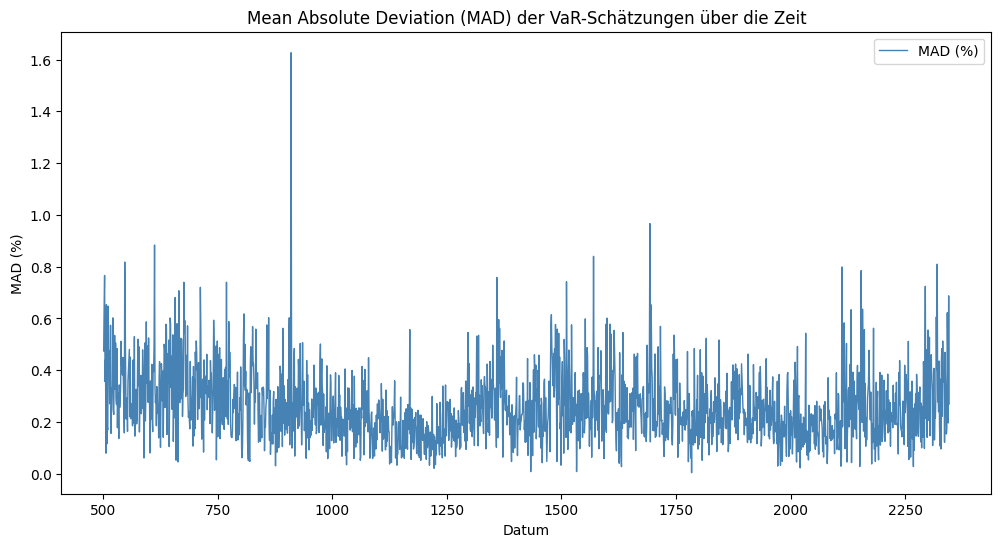

In [684]:
plt.figure(figsize=(12, 6))
plt.plot(mad.index, mad.values*100, color="steelblue", lw=1)
plt.xlabel("Datum")
plt.ylabel("MAD (%)")
plt.title("Mean Absolute Deviation (MAD) der VaR-Schätzungen über die Zeit")
plt.legend(["MAD (%)"], loc="upper right")
plt.show()

## Supplement: Rolling window with multiple GARCH models and copulas

* GARCH models: GARCH(1,1) with t-distributed and skew t-distributed innovations
* Copulas: Gaussian, t, Clayton

# SANDBOX

### Understanding of GARCH spec

In [ ]:
def fit_garch(returns, scale=100):
    """
    Fit a ARMA(1,1)-GARCH(1,1) model to the returns and return the fitted model.
    """
    model = arch_model(returns*scale, mean="AR", lags=1, vol="Garch", p=1, q=1, dist="t") # scale returns for better convergence

    res = model.fit(disp="off", show_warning=False) # disp="off" to suppress output, show_warning=False to ignore convergence warnings

    return res

#### GARCH with mean=AR(1) 

In [178]:
res_nvda = fit_garch(returns["NVDA"], scale=SCALE)
res_nvda.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              AR - GARCH Model Results                              
====================================================================================
Dep. Variable:                         NVDA   R-squared:                       0.004
Mean Model:                              AR   Adj. R-squared:                  0.003
Vol Model:                            GARCH   Log-Likelihood:               -2883.00
Distribution:      Standardized Student's t   AIC:                           5778.01
Method:                  Maximum Likelihood   BIC:                           5808.18
                                              No. Observations:                 1128
Date:                      Wed, May 13 2026   Df Residuals:                     1126
Time:                              14:06:58   Df Model:                            2
                                  Mean Model                                 
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
Const          0.3283  8.371e-02      3.922  8.787e-05      [  0.164,  0.492]
NVDA[1]       -0.0262  3.013e-02     -0.871      0.384 [-8.531e-02,3.282e-02]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.4278      0.167      2.560  1.047e-02   [  0.100,  0.755]
alpha[1]       0.0921  2.413e-02      3.818  1.346e-04 [4.483e-02,  0.139]
beta[1]        0.8736  3.063e-02     28.524 5.976e-179   [  0.814,  0.934]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             6.6004      1.435      4.599  4.251e-06 [  3.787,  9.413]
========================================================================

Covariance estimator: robust
"""

In [180]:
res_nvda.params

Const       0.328279
NVDA[1]    -0.026244
omega       0.427803
alpha[1]    0.092126
beta[1]     0.873582
nu          6.600357
Name: params, dtype: float64

In [182]:
# Mittelwert extrahieren
res_nvda.params["Const"]

np.float64(0.328278643304416)

In [184]:
res_nvda.resid[:10]

Date
2020-01-03         NaN
2020-01-06    0.047891
2020-01-07    0.886063
2020-01-08   -0.109317
2020-01-09    0.768913
2020-01-10    0.233907
2020-01-13    2.772818
2020-01-14   -2.130101
2020-01-15   -1.071612
2020-01-16    1.012465
Name: resid, dtype: float64

In [185]:
res_nvda.std_resid[:10]

Date
2020-01-03         NaN
2020-01-06    0.015767
2020-01-07    0.304131
2020-01-08   -0.038856
2020-01-09    0.283745
2020-01-10    0.089064
2020-01-13    1.091099
2020-01-14   -0.818186
2020-01-15   -0.411949
2020-01-16    0.398812
Name: std_resid, dtype: float64

In [186]:
res_nvda.resid[:10]/res_nvda.conditional_volatility[:10]

Date
2020-01-03         NaN
2020-01-06    0.015767
2020-01-07    0.304131
2020-01-08   -0.038856
2020-01-09    0.283745
2020-01-10    0.089064
2020-01-13    1.091099
2020-01-14   -0.818186
2020-01-15   -0.411949
2020-01-16    0.398812
dtype: float64

#### GARCH with mean=ZERO

In [187]:
model_nvda2 = arch_model(returns["NVDA"]*100, mean="Zero", vol="Garch", p=1, q=1, dist="t") # scale returns for better convergence
res_nvda2 = model_nvda2.fit(disp="off", show_warning=False) # disp="off" to suppress output, show_warning=False to ignore convergence warnings
res_nvda2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                          Zero Mean - GARCH Model Results                           
====================================================================================
Dep. Variable:                         NVDA   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.001
Vol Model:                            GARCH   Log-Likelihood:               -2892.58
Distribution:      Standardized Student's t   AIC:                           5793.16
Method:                  Maximum Likelihood   BIC:                           5813.28
                                              No. Observations:                 1129
Date:                      Wed, May 13 2026   Df Residuals:                     1129
Time:                              14:17:44   Df Model:                            0
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.4377      0.161      2.713  6.676e-03   [  0.121,  0.754]
alpha[1]       0.0898  2.344e-02      3.830  1.282e-04 [4.383e-02,  0.136]
beta[1]        0.8749  2.914e-02     30.026 4.550e-198   [  0.818,  0.932]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             6.7466      1.502      4.491  7.102e-06 [  3.802,  9.691]
========================================================================

Covariance estimator: robust
"""

In [188]:
res_nvda2.params

omega       0.437701
alpha[1]    0.089767
beta[1]     0.874851
nu          6.746551
Name: params, dtype: float64

In [189]:
res_nvda2.resid[:10]

Date
2020-01-03   -1.613537
2020-01-06    0.418515
2020-01-07    1.203359
2020-01-08    0.187381
2020-01-09    1.092274
2020-01-10    0.533520
2020-01-13    3.087095
2020-01-14   -1.882840
2020-01-15   -0.693920
2020-01-16    1.358955
Name: resid, dtype: float64

#### GARCH with mean=Constant

In [198]:
model_nvda3 = arch_model(returns["NVDA"]*100, mean="Constant", vol="Garch", p=1, q=1, dist="t") # scale returns for better convergence
res_nvda3 = model_nvda3.fit(disp="off", show_warning=False) # disp="off" to suppress output, show_warning=False to ignore convergence warnings
res_nvda3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                        Constant Mean - GARCH Model Results                         
====================================================================================
Dep. Variable:                         NVDA   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -2885.46
Distribution:      Standardized Student's t   AIC:                           5780.93
Method:                  Maximum Likelihood   BIC:                           5806.07
                                              No. Observations:                 1129
Date:                      Wed, May 13 2026   Df Residuals:                     1128
Time:                              14:45:13   Df Model:                            1
                               Mean Model                               
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.3160  8.153e-02      3.875  1.065e-04 [  0.156,  0.476]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.4338      0.165      2.633  8.452e-03   [  0.111,  0.757]
alpha[1]       0.0935  2.406e-02      3.888  1.010e-04 [4.639e-02,  0.141]
beta[1]        0.8717  3.015e-02     28.910 8.912e-184   [  0.813,  0.931]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             6.5961      1.428      4.620  3.828e-06 [  3.798,  9.394]
========================================================================

Covariance estimator: robust
"""

In [199]:
res_nvda3.params

mu          0.315955
omega       0.433780
alpha[1]    0.093540
beta[1]     0.871723
nu          6.596050
Name: params, dtype: float64

In [202]:
res_nvda3.params["mu"]

np.float64(0.31595547378316763)

In [200]:
res_nvda2.resid[:10]

Date
2020-01-03   -1.613537
2020-01-06    0.418515
2020-01-07    1.203359
2020-01-08    0.187381
2020-01-09    1.092274
2020-01-10    0.533520
2020-01-13    3.087095
2020-01-14   -1.882840
2020-01-15   -0.693920
2020-01-16    1.358955
Name: resid, dtype: float64

In [ ]:
# residuals with mean = zero 
# residuals subtracted by model with mean = constant
res_nvda2.resid[:10] - res_nvda3.params["mu"]

Date
2020-01-03   -1.929492
2020-01-06    0.102560
2020-01-07    0.887403
2020-01-08   -0.128575
2020-01-09    0.776318
2020-01-10    0.217565
2020-01-13    2.771140
2020-01-14   -2.198795
2020-01-15   -1.009876
2020-01-16    1.042999
Name: resid, dtype: float64

In [ ]:
# Residuals with mean = constant
res_nvda3.resid[:10]

Date
2020-01-03   -1.929492
2020-01-06    0.102560
2020-01-07    0.887403
2020-01-08   -0.128575
2020-01-09    0.776318
2020-01-10    0.217565
2020-01-13    2.771140
2020-01-14   -2.198795
2020-01-15   -1.009876
2020-01-16    1.042999
Name: resid, dtype: float64

In [236]:
fc_nvda3_mean = res_nvda3.forecast(horizon=1).mean.iloc[-1, 0] / 100 # scale back the mean to the original return scale
fc_nvda3_mean

np.float64(0.003159554737831676)

#### ARMA-GARCH with statsmodel package

Ein echtes ARMA ist im arch-Package eingeschränkt; oft macht man:

1. ARMA fit mit statsmodels
2. Residuen extrahieren
3. GARCH auf Residuen

Note: Forecast
* den Mean direkt mit dem GARCH-Modell forecasten, aber nur wenn das Mean-Modell auch im GARCH-Modell enthalten ist.
* Da in dem zweistufigen Ansatz das GARCH-Modell keinen Mean-Prozess beinhaltet, kann damit nur die Varianz vorhergesagt werden
* Grund: im GARCH-Modell explizit `mean="Zero"` gesetzt
* Deshalb den Mean Forecast vom ARMA-Modell


In [204]:
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
# 1. ARMA(1, 0, 1) fitten
arma_model_nvda = ARIMA(returns["NVDA"]*100, order=(1, 0, 1))
arma_res_nvda = arma_model_nvda.fit()
arma_res_nvda.summary()

/opt/anaconda3/envs/ml/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/ml/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/ml/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   NVDA   No. Observations:                 1129
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -2972.072
Date:                Wed, 13 May 2026   AIC                           5952.144
Time:                        14:52:40   BIC                           5972.260
Sample:                             0   HQIC                          5959.745
                               - 1129                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2684      0.096      2.788      0.005       0.080       0.457
ar.L1         -0.3438      0.260     -1.324      0.185      -0.853       0.165
ma.L1          0.2581      0.272      0.950      0.342      -0.274       0.790
sigma2        11.3254      0.298     37.949      0.000      10.740      11.910
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               574.34
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               0.87   Skew:                             0.15
Prob(H) (two-sided):                  0.17   Kurtosis:                         6.48
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [211]:
# 2. Residuen extrahieren
arma_resid_nvda = arma_res_nvda.resid
arma_resid_nvda[:10]

Date
2020-01-03   -1.881902
2020-01-06   -0.015157
2020-01-07    0.990526
2020-01-08   -0.015172
2020-01-09    0.799981
2020-01-10    0.341946
2020-01-13    2.821636
2020-01-14   -1.910368
2020-01-15   -1.208821
2020-01-16    1.071744
dtype: float64

In [ ]:
# 3. GARCH(1,1)-t fitten
# Warum mean="Zero"?
# Weil der Mean-Prozess bereits durch ARMA modelliert wurde.
model_nvda4 = arch_model(arma_resid_nvda, mean="Zero", vol="GARCH", p=1, q=1, dist="t")
res_nvda4 = model_nvda4.fit(disp="off", show_warning=False)
res_nvda4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                          Zero Mean - GARCH Model Results                           
====================================================================================
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.001
Vol Model:                            GARCH   Log-Likelihood:               -2887.69
Distribution:      Standardized Student's t   AIC:                           5783.38
Method:                  Maximum Likelihood   BIC:                           5803.50
                                              No. Observations:                 1129
Date:                      Wed, May 13 2026   Df Residuals:                     1129
Time:                              14:55:10   Df Model:                            0
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.4146      0.169      2.459  1.394e-02 [8.411e-02,  0.745]
alpha[1]       0.0892  2.423e-02      3.682  2.318e-04 [4.172e-02,  0.137]
beta[1]        0.8774  3.117e-02     28.147 2.578e-174   [  0.816,  0.939]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             6.7133      1.488      4.512  6.426e-06 [  3.797,  9.630]
========================================================================

Covariance estimator: robust
"""

In [247]:
res_nvda4.std_resid[:10]

Date
2020-01-03   -0.633472
2020-01-06   -0.005207
2020-01-07    0.353533
2020-01-08   -0.005581
2020-01-09    0.304578
2020-01-10    0.133868
2020-01-13    1.137803
2020-01-14   -0.748107
2020-01-15   -0.475541
2020-01-16    0.429918
Name: std_resid, dtype: float64

In [213]:
# Freiheitsgrade der t-Verteilung
res_nvda4.params["nu"]

np.float64(6.7132778204492025)

In [ ]:
# Forecast values for the next day (horizon=1)
# Sigma forecast aus GARCH model
sigma_nvda4 = res_nvda4.forecast(horizon=1).variance.iloc[-1, 0] ** 0.5  / 100 # ** 0.5 to get the standard deviation from the variance
# Mean-Forecast aus ARMA model
mu_nvda4 = res_nvda4.forecast(horizon=1).mean.iloc[-1, 0] / 100 # scale back the mean to the original return scale

mu_nvda4

np.float64(0.0)

In [244]:
# Alternative: Mean-Forecast direkt aus ARMA model
mu_nvda4 = arma_res_nvda.forecast(steps=1).iloc[0] / 100 # scale back the mean to the original return scale
mu_nvda4

/opt/anaconda3/envs/ml/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


np.float64(0.002858841189830144)

In [ ]:
# Mean forecast aus GARCH model mit Mean="Const"
fc_nvda3_mean

np.float64(0.003159554737831676)

### Fitting GARCH model

In [ ]:
res_aapl = fit_garch(returns["AAPL"])
res_jpm = fit_garch(returns["JPM"])

In [123]:
# Degree of freedom for the t-distribution of the standardized residuals
nu_aapl = res_aapl.params["nu"]
nu_jpm = res_jpm.params["nu"]

nu_aapl, nu_jpm

(np.float64(5.711445779124602), np.float64(5.695319945549439))

In [ ]:
# Standardized residuals
residuals_std_aapl = res_aapl.std_resid 
residuals_std_jpm = res_jpm.std_resid

# Combine standardized residuals into a matrix for copula fitting
matrix_residuals_std = np.column_stack((residuals_std_aapl, residuals_std_jpm)) 
matrix_residuals_std

array([[-0.46026842, -0.57458822],
       [ 0.29209707, -0.08032252],
       [-0.26810081, -0.81802016],
       ...,
       [ 0.96435926, -0.33559904],
       [ 0.14365503,  0.61189905],
       [-0.95152938,  1.16462483]], shape=(1129, 2))

In [152]:
matrix_residuals_std2 = pd.DataFrame({"AAPL": residuals_std_aapl, "JPM": residuals_std_jpm})
matrix_residuals_std2

,AAPL,JPM
Date,,
2020-01-03,-0.460268,-0.574588
2020-01-06,0.292097,-0.080323
2020-01-07,-0.268101,-0.818020
2020-01-08,0.694984,0.304348
2020-01-09,0.953849,0.122560
...,...,...
2024-06-24,0.091446,0.883109
2024-06-25,0.161697,-0.385154
2024-06-26,0.964359,-0.335599


In [153]:
# Forecast values for the next day (horizon=1)
mu_aapl = res_aapl.forecast(horizon=1).mean.iloc[-1, 0] / 100 # scale back the mean to the original return scale
sigma_aapl = res_aapl.forecast(horizon=1).variance.iloc[-1, 0] ** 0.5  / 100 # ** 0.5 to get the standard deviation from the variance; scale back to the original return scale

mu_jpm = res_jpm.forecast(horizon=1).mean.iloc[-1, 0] / 100
sigma_jpm = res_jpm.forecast(horizon=1).variance.iloc[-1, 0] ** 0.5 / 100

mu_aapl, sigma_aapl

(np.float64(0.0012113870362165967), np.float64(0.018481205829487826))

### Fitting copula - Copulae Example

----------- Copulae example -----------

In [137]:
from copulae.datasets import load_residuals

residuals = load_residuals()
residuals.head()

,A,B,C,D,E,F,G
0,0.730967,0.530860,0.287320,1.193049,0.019040,1.100507,0.278214
1,2.067853,-1.181313,-2.546173,0.381538,-0.038734,0.269874,-0.603940
2,-2.181835,0.380326,0.928632,-0.316861,0.106473,-0.324854,-0.447824
3,0.445040,0.734531,-0.133299,-0.374091,0.173616,-0.319402,-0.775106
4,0.296363,3.024053,0.815791,1.168521,0.134044,1.110424,1.705190


In [96]:
residuals.shape

(394, 7)

In [97]:
matrix_residuals_std.shape

(1129, 2)

In [142]:
nodim = matrix_residuals_std.shape[1]
nodim

2

----------- Copulae example -----------

### Fitting copula

In [324]:
# Pseudo observations for copula fitting
u = pseudo_obs(matrix_residuals_std)
u

AssertionError: Data can only be 1 or 2 dimensional

In [323]:
# Copula fitting
copula_gaussian = GaussianCopula(dim=matrix_residuals_std.shape[1]) # Initialize a Gaussian copula

copula_gauss_fit = copula_gaussian.fit(u) # Fit the copula to the pseudo-observations

AttributeError: 'dict' object has no attribute 'shape'

In [172]:
# Sampling: Simulate from the fitted copula; values are in the unit square [0,1] because they are pseudo-observations
u_sim = copula_gauss_fit.random(N_SIM)  

u_sim

array([[0.19261216, 0.39551055],
       [0.5860545 , 0.4522988 ],
       [0.1849076 , 0.14576811],
       ...,
       [0.95768703, 0.48746703],
       [0.34137884, 0.36865164],
       [0.31954628, 0.54428091]], shape=(10000, 2))

In [ ]:
# Back-transform the simulated pseudo-observations to the original scale using the inverse CDF of the standardized residuals
# Uniform -> t-verteilte Residuen
z_sim_aapl = t.ppf(u_sim[:, 0], df=nu_aapl) 
z_sim_jpm = t.ppf(u_sim[:, 1], df=nu_jpm)

z_sim_aapl, z_sim_jpm

(array([ 2.96479562,  1.27909427,  1.16868669, ...,  0.16978892,
        -0.69599152, -0.32938989], shape=(10000,)),
 array([1.06753536, 0.04944186, 1.54375717, ..., 2.0754211 , 0.0881333 ,
        1.85348216], shape=(10000,)))

### Computation of PF return

In [ ]:
# Simulated returns
r_sim_aapl = mu_aapl + sigma_aapl * z_sim_aapl
r_sim_jpm = mu_jpm + sigma_jpm * z_sim_jpm
r_sim_aapl, r_sim_jpm

(array([ 0.05600439,  0.02485059,  0.02281013, ...,  0.00434929,
        -0.01165138, -0.00487614], shape=(10000,)),
 array([0.01473818, 0.00175687, 0.02081029, ..., 0.02758932, 0.00225021,
        0.02475947], shape=(10000,)))

In [165]:
r_sim = np.column_stack((r_sim_aapl, r_sim_jpm))
r_sim

array([[ 0.05600439,  0.01473818],
       [ 0.02485059,  0.00175687],
       [ 0.02281013,  0.02081029],
       ...,
       [ 0.00434929,  0.02758932],
       [-0.01165138,  0.00225021],
       [-0.00487614,  0.02475947]], shape=(10000, 2))

In [166]:
w = np.ones(matrix_residuals_std.shape[1]) / matrix_residuals_std.shape[1] # Equal weights for the portfolio
w

array([0.5, 0.5])

In [ ]:
np.ones(len(TICKERS)) / len(TICKERS)

In [168]:
# Simulated portfolio returns
r_sim_portfolio = w[0] * r_sim_aapl + w[1] * r_sim_jpm
r_sim_portfolio

array([ 0.03537128,  0.01330373,  0.02181021, ...,  0.01596931,
       -0.00470058,  0.00994167], shape=(10000,))

In [167]:
r_sim_pf = r_sim @ w
r_sim_pf

array([ 0.03537128,  0.01330373,  0.02181021, ...,  0.01596931,
       -0.00470058,  0.00994167], shape=(10000,))

### Risk forecasts

In [169]:
# Risk measure
VaR_95 = np.percentile(r_sim_pf, ALPHA)
VaR_95

np.float64(-0.0767792518775959)

## SANDBOX with R implementation

### Load return data

In [23]:
returns_aapl = returns["AAPL"]
returns_jpm = returns["JPM"]

### Using R's rugarch package in python

In [6]:
# rpy2 
import rpy2

import rpy2.robjects as ro
from rpy2.robjects.packages import importr # importr is used to import R packages


In [13]:
R --version

NameError: name 'R' is not defined

In [10]:
# loading R packages
utils = importr('utils') # utils is used to install R packages

copula = importr("copula")
rugarch = importr("rugarch")

In [11]:
# check versions of R packages
rugarch.__version__

'1.5-5'

In [12]:
# check versions of R packages
copula.__version__

'1.1-7'

#### Fitting the GARCH model

In [14]:
# GARCH(1,1) specification in R
spec = rugarch.ugarchspec(variance_model = ro.ListVector({'model': "sGARCH", 'garchOrder': ro.IntVector([1, 1])}), # specify GARCH(1,1) model
                          mean_model = ro.ListVector({'armaOrder': ro.IntVector([1, 1]), 'include.mean': True}), # specify ARMA(1,1) model for the mean
                          distribution_model = "std") # specify Student's t distribution for the innovations

In [24]:
# fit the model to the returns (scale returns for better convergence)
fit_aapl = rugarch.ugarchfit(spec, ro.FloatVector(returns_aapl.values * 100)) # fit the model to the returns (scale returns for better convergence)
fit_jpm = rugarch.ugarchfit(spec, ro.FloatVector(returns_jpm.values * 100)) # fit the model to the returns (scale returns for better convergence)

#### Extracting standardized residuals

In [25]:
residuals_aapl = np.array(rugarch.residuals(fit_aapl)) # Get the residuals from the fitted model
sigma_aapl = np.array(rugarch.sigma(fit_aapl)) # Get the conditional volatility from the fitted model
residuals_standardized_aapl = residuals_aapl / sigma_aapl # Standardize the residuals

residuals_jpm = np.array(rugarch.residuals(fit_jpm))
sigma_jpm = np.array(rugarch.sigma(fit_jpm))
residuals_standardized_jpm = residuals_jpm / sigma_jpm

#### Forecast values

In [26]:
# One-step-ahead forecast for mean and conditional volatility
forecast_aapl = rugarch.ugarchforecast(fit_aapl, n_ahead=1)
forecast_jpm = rugarch.ugarchforecast(fit_jpm, n_ahead=1)

In [27]:
# Mean forecast for the next day (scale back the mean forecast)
mu_forecast_aapl = np.array(rugarch.fitted(forecast_aapl))[0] / 100 # scale back the mean forecast
mu_forecast_jpm = np.array(rugarch.fitted(forecast_jpm))[0] / 100 # scale back the mean forecast

# Volatility forecast for the next day (scale back the volatility forecast)
sigma_forecast_aapl = np.array(rugarch.sigma(forecast_aapl))[0] / 100 # scale back the volatility forecast
sigma_forecast_jpm = np.array(rugarch.sigma(forecast_jpm))[0] / 100 # scale back the volatility forecast

In [29]:
mu_forecast_aapl, sigma_forecast_aapl, mu_forecast_jpm, sigma_forecast_jpm

(array([0.00147206]),
 array([0.01847455]),
 array([0.00103727]),
 array([0.01276176]))

In [35]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

matrix = np.array([a, b])
matrix

array([[1, 2, 3],
       [4, 5, 6]])

#### Pseudo observations

In [40]:
residuals_standardized_aapl

array([[-0.5360317 ],
       [ 0.32408252],
       [-0.30942911],
       ...,
       [ 0.95810541],
       [ 0.16134835],
       [-0.93760526]], shape=(1129, 1))

In [ ]:
# Speichern der standardisierten Residuen in der Matrix
residuals_standardized_matrix = np.column_stack((residuals_standardized_aapl, residuals_standardized_jpm))
residuals_standardized_matrix2 = np.array((residuals_standardized_aapl, residuals_standardized_jpm)) # rausnhemen
residuals_standardized_matrix, residuals_standardized_matrix2

(array([[-0.5360317 , -0.69340181],
        [ 0.32408252, -0.10065144],
        [-0.30942911, -0.96328314],
        ...,
        [ 0.95810541, -0.34285771],
        [ 0.16134835,  0.61168582],
        [-0.93760526,  1.1652201 ]], shape=(1129, 2)),
 array([[[-0.5360317 ],
         [ 0.32408252],
         [-0.30942911],
         ...,
         [ 0.95810541],
         [ 0.16134835],
         [-0.93760526]],
 
        [[-0.69340181],
         [-0.10065144],
         [-0.96328314],
         ...,
         [-0.34285771],
         [ 0.61168582],
         [ 1.1652201 ]]], shape=(2, 1129, 1)))

In [51]:
u2 = pseudo_obs(residuals_standardized_matrix) # Get the pseudo-observations from the standardized residuals
u2

array([[0.27168142, 0.22212389],
       [0.65486726, 0.47079646],
       [0.36548673, 0.1460177 ],
       ...,
       [0.85221239, 0.35309735],
       [0.58230088, 0.76725664],
       [0.14159292, 0.91150442]], shape=(1129, 2))

In [ ]:
u = copula.pobs(ro.FloatVector(residuals_standardized_matrix)) # Get the pseudo-observations from the standardized residuals
u

NotImplementedError: Conversion 'py2rpy' not defined for objects of type '<class 'numpy.ndarray'>'

In [56]:
u2.shape[1]

2

#### Copulas

In [60]:
# Gaussian copula
cop_gaussian = copula.normalCopula(dim=u2.shape[1], dispstr="un")

fit_gaussian = copula.fitCopula(cop_gaussian, u2, method = "mpl") # Fit the Gaussian copula to the pseudo-observations

NotImplementedError: Conversion 'py2rpy' not defined for objects of type '<class 'numpy.ndarray'>'